In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import shap
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier


G:\projs\Semantix\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 - RowNumber: The sequential number assigned to each row in the dataset.
 - CustomerId: A unique identifier for each customer.
 - Surname: The surname of the customer.
 - CreditScore: The credit score of the customer.
 - Geography: The geographical location of the customer (e.g., country or region).
 - Gender: The gender of the customer.
 - Age: The age of the customer.
 - Tenure: The number of years the customer has been with the bank.
 - Balance: The account balance of the customer.
 - NumOfProducts: The number of bank products the customer has.
 - HasCrCard: Indicates whether the customer has a credit card (binary: yes/no).
 - IsActiveMember: Indicates whether the customer is an active member (binary: yes/no).
 - EstimatedSalary: The estimated salary of the customer.
 - Exited: Indicates whether the customer has exited the bank (binary: yes/no).

In [2]:
df = pd.read_csv("Churn_Modelling.csv", delimiter=',')

df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [4]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
df['Geography'].unique()

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

In [7]:
df['Gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [8]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [9]:
sns.set_style('white')

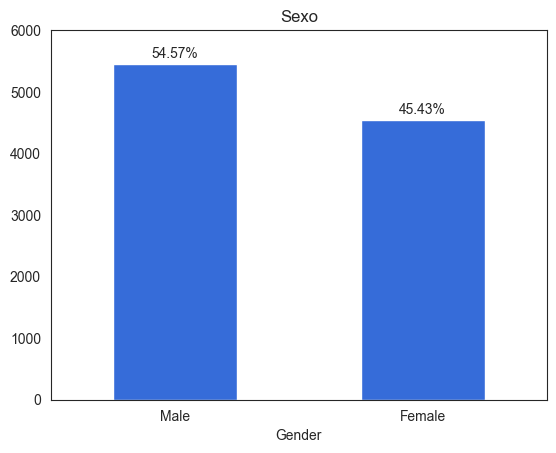

In [10]:
contagem = df['Gender'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100

ax = contagem.plot(kind='bar')
ax.set_ylim(0, contagem.max() * 1.1)
ax.bar_label(ax.containers[0], labels=[f'{p:.2f}%' for p in porcentagem], padding=2)

plt.title('Sexo')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.show()

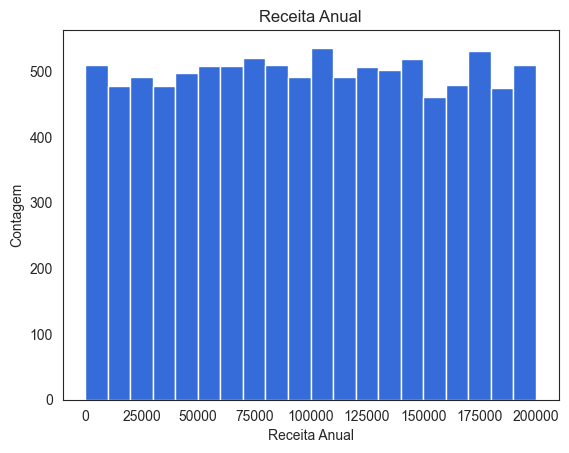

In [11]:
bins = np.arange(df['EstimatedSalary'].min(), df['EstimatedSalary'].max() + 10000, 10000)

ax = df['EstimatedSalary'].plot(kind='hist', bins=bins, edgecolor='white')
ax.set_xlabel('Receita Anual')
ax.set_ylabel('Contagem')
ax.set_title('Receita Anual')
plt.show()


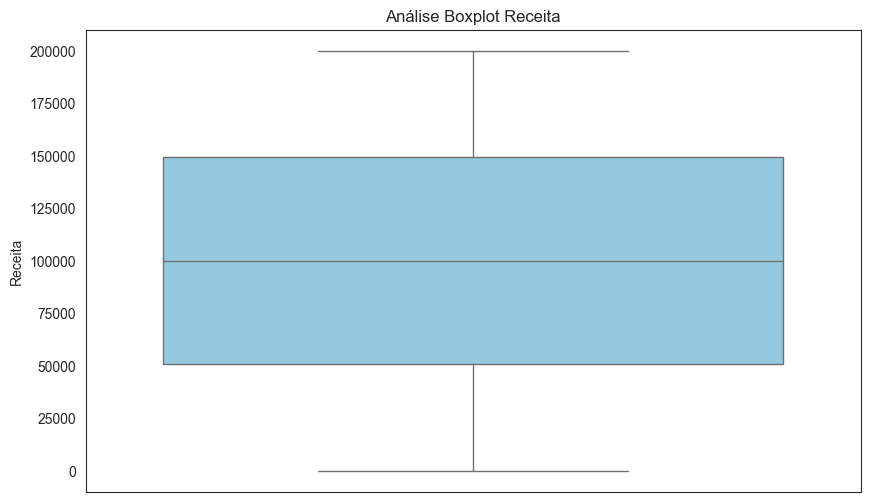

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, y='EstimatedSalary', color='skyblue')
plt.title('Análise Boxplot Receita')
plt.ylabel('Receita')
plt.show()

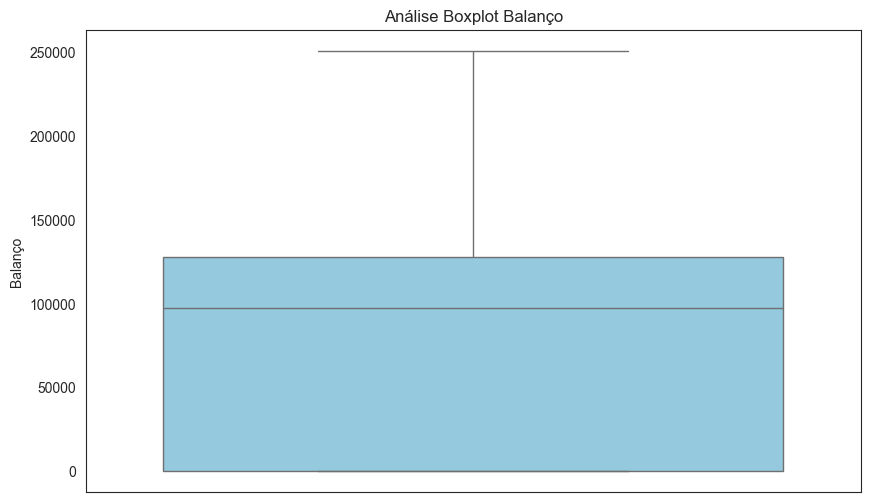

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, y='Balance', color='skyblue')
plt.title('Análise Boxplot Balanço')
plt.ylabel('Balanço')
plt.show()

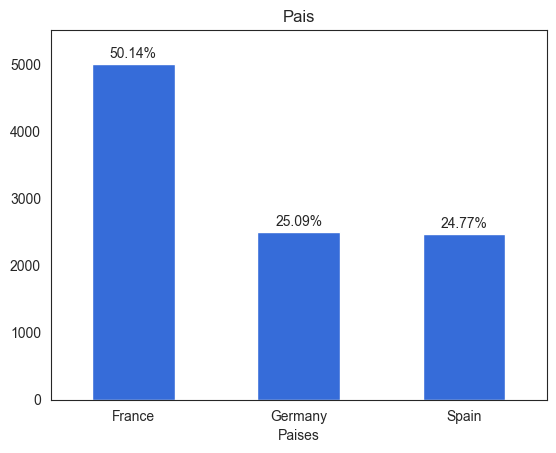

In [14]:
contagem = df['Geography'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100

ax = contagem.plot(kind='bar')
ax.set_ylim(0, contagem.max() * 1.1)
ax.bar_label(ax.containers[0], labels=[f'{p:.2f}%' for p in porcentagem], padding=2)

plt.title('Pais')
plt.xlabel('Paises')
plt.xticks(rotation=0)
plt.show()

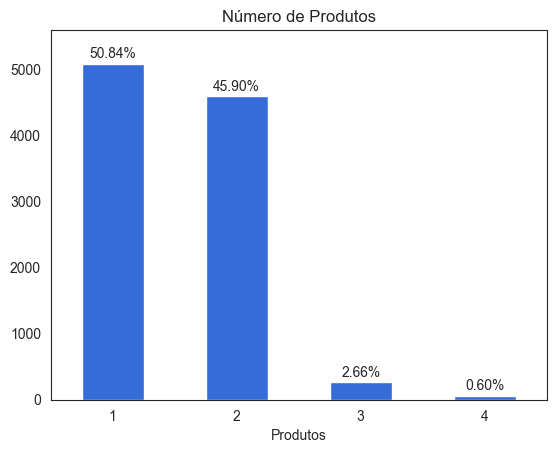

In [15]:
contagem = df['NumOfProducts'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100

ax = contagem.plot(kind='bar')
ax.set_ylim(0, contagem.max() * 1.1)
ax.bar_label(ax.containers[0], labels=[f'{p:.2f}%' for p in porcentagem], padding=2)

plt.title('Número de Produtos')
plt.xlabel('Produtos')
plt.xticks(rotation=0)
plt.show()

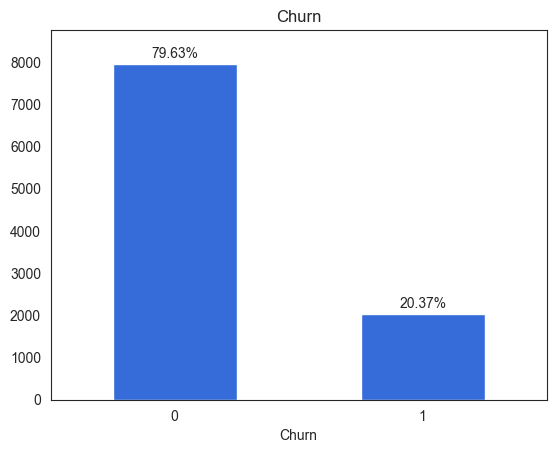

In [16]:
contagem = df['Exited'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100

ax = contagem.plot(kind='bar')
ax.set_ylim(0, contagem.max() * 1.1)
ax.bar_label(ax.containers[0], labels=[f'{p:.2f}%' for p in porcentagem], padding=2)

plt.title('Churn')
plt.xlabel('Churn')
plt.xticks(rotation=0)
plt.show()

## Análise Exploratória: Distribuição de Perfil e Taxas de Churn por Segmento

Nesta seção, dividimos a análise visual em duas perspectivas essenciais:
1. **Distribuição do Perfil dos Clientes por Churn (P(Segmento | Churn)):** Mostra a composição categórica dentro do grupo de clientes que saíram (1) vs. os que ficaram (0).
2. **Taxa de Churn por Segmento (P(Churn | Segmento)):** Revela a proporção direta de clientes que cancelaram dentro de cada categoria específica (evitando viés de contagem em bases desbalanceadas).


In [17]:
df_grouped = df.groupby(['Exited', 'Gender']).size().reset_index(name='count')
sexo_por_churn = df_grouped.groupby('Exited')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / sexo_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Exited', y='percent',
             color='Gender',
             barmode='stack',
             text=df_grouped['percent'].map(lambda v: f'{v:.1f}%'),
             labels={'Exited': 'Churn', 'percent': 'Porcentagem', 'Gender': 'Sexo'})

fig.update_layout(title='Relação entre Churn e Sexo',
                  yaxis_title='Porcentagem',
                  legend_title='Sexo')
fig.show()

In [18]:
bins = [-1, 2, 4, 6, 8, 10]
labels = ['0-2 anos', '3-4 anos', '5-6 anos', '7-8 anos', '9-10 anos']
df['Tenure_Bins'] = pd.cut(df['Tenure'], bins=bins, labels=labels)

df_grouped = df.groupby(['Exited', 'Tenure_Bins']).size().reset_index(name='count')
sexo_por_churn = df_grouped.groupby('Exited')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / sexo_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Exited', y='percent',
             color='Tenure_Bins',
             barmode='stack',
             text=df_grouped['percent'].map(lambda v: f'{v:.1f}%'),
             labels={'Exited': 'Churn', 'percent': 'Porcentagem', 'Tenure_Bins': 'Tempo como Cliente'})

fig.update_layout(title='Relação entre Churn e Tempo como Cliente',
                  yaxis_title='Porcentagem',
                  legend_title='Tempo como Cliente')
fig.show()

In [19]:
bins = list(range(0, int(df['EstimatedSalary'].max()) + 50000, 50000))
labels = [f'{i}-{i + 50000}' for i in bins[:-1]]
df['EstimatedSalary_Bins'] = pd.cut(df['EstimatedSalary'], bins=bins, labels=labels, include_lowest=True)

df_grouped = df.groupby(['Exited', 'EstimatedSalary_Bins']).size().reset_index(name='count')
sexo_por_churn = df_grouped.groupby('Exited')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / sexo_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Exited', y='percent',
             color='EstimatedSalary_Bins',
             barmode='stack',
             text=df_grouped['percent'].map(lambda v: f'{v:.1f}%'),
             labels={'Exited': 'Churn', 'percent': 'Porcentagem', 'EstimatedSalary_Bins': 'Receita'})

fig.update_layout(title='Relação entre Churn e Receita',
                  yaxis_title='Porcentagem',
                  legend_title='Receita')
fig.show()

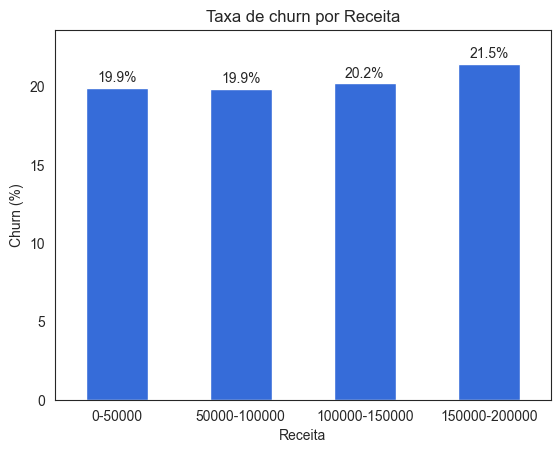

In [20]:
df_rate = df.groupby('EstimatedSalary_Bins')['Exited'].mean().reset_index(name='churn_rate')
df_rate['churn_rate'] = df_rate['churn_rate'] * 100

ax = df_rate.plot(kind='bar', x='EstimatedSalary_Bins', y='churn_rate', legend=False)
ax.set_ylim(0, df_rate['churn_rate'].max() * 1.1)
ax.bar_label(ax.containers[0], labels=[f'{v:.1f}%' for v in df_rate['churn_rate']], padding=2)
plt.title('Taxa de churn por Receita')
plt.xlabel('Receita')
plt.ylabel('Churn (%)')
plt.xticks(rotation=0)
plt.show()

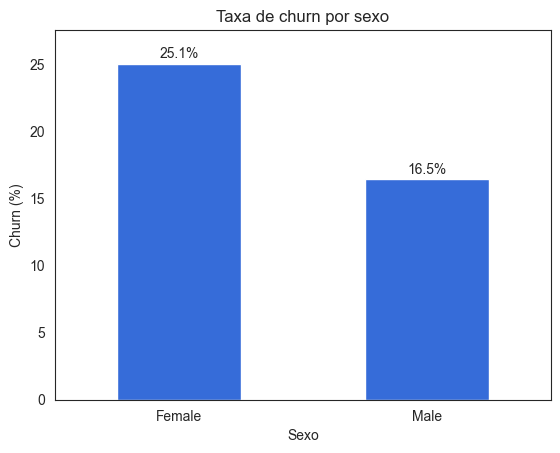

In [21]:
df_rate = df.groupby('Gender')['Exited'].mean().reset_index(name='churn_rate')
df_rate['churn_rate'] = df_rate['churn_rate'] * 100

ax = df_rate.plot(kind='bar', x='Gender', y='churn_rate', legend=False)
ax.set_ylim(0, df_rate['churn_rate'].max() * 1.1)
ax.bar_label(ax.containers[0], labels=[f'{v:.1f}%' for v in df_rate['churn_rate']], padding=2)
plt.title('Taxa de churn por sexo')
plt.xlabel('Sexo')
plt.ylabel('Churn (%)')
plt.xticks(rotation=0)
plt.show()

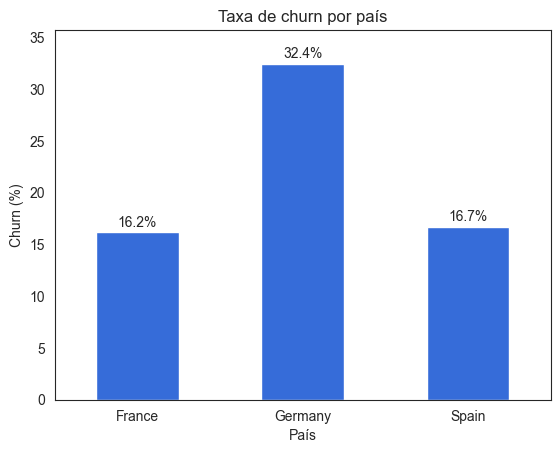

In [22]:
df_rate = df.groupby('Geography')['Exited'].mean().reset_index(name='churn_rate')
df_rate['churn_rate'] = df_rate['churn_rate'] * 100

ax = df_rate.plot(kind='bar', x='Geography', y='churn_rate', legend=False)
ax.set_ylim(0, df_rate['churn_rate'].max() * 1.1)
ax.bar_label(ax.containers[0], labels=[f'{v:.1f}%' for v in df_rate['churn_rate']], padding=2)
plt.title('Taxa de churn por país')
plt.xlabel('País')
plt.ylabel('Churn (%)')
plt.xticks(rotation=0)
plt.show()

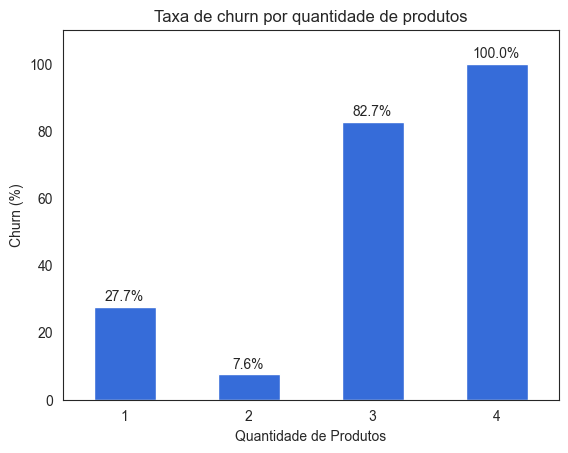

In [23]:
df_rate = df.groupby('NumOfProducts')['Exited'].mean().reset_index(name='churn_rate')
df_rate['churn_rate'] = df_rate['churn_rate'] * 100

ax = df_rate.plot(kind='bar', x='NumOfProducts', y='churn_rate', legend=False)
ax.set_ylim(0, df_rate['churn_rate'].max() * 1.1)
ax.bar_label(ax.containers[0], labels=[f'{v:.1f}%' for v in df_rate['churn_rate']], padding=2)
plt.title('Taxa de churn por quantidade de produtos')
plt.xlabel('Quantidade de Produtos')
plt.ylabel('Churn (%)')
plt.xticks(rotation=0)
plt.show()

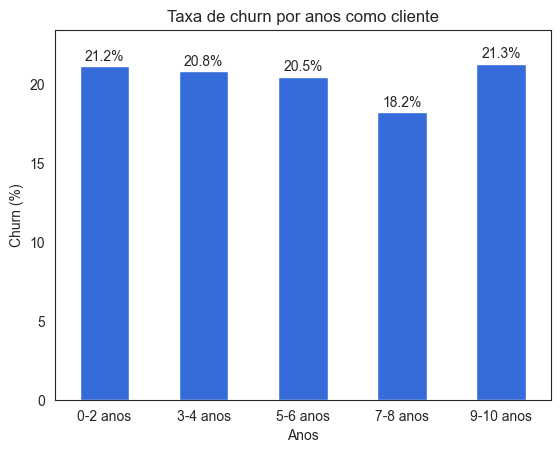

In [24]:
df_rate = df.groupby('Tenure_Bins')['Exited'].mean().reset_index(name='churn_rate')
df_rate['churn_rate'] = df_rate['churn_rate'] * 100

ax = df_rate.plot(kind='bar', x='Tenure_Bins', y='churn_rate', legend=False)
ax.set_ylim(0, df_rate['churn_rate'].max() * 1.1)
ax.bar_label(ax.containers[0], labels=[f'{v:.1f}%' for v in df_rate['churn_rate']], padding=2)
plt.title('Taxa de churn por anos como cliente')
plt.xlabel('Anos')
plt.ylabel('Churn (%)')
plt.xticks(rotation=0)
plt.show()

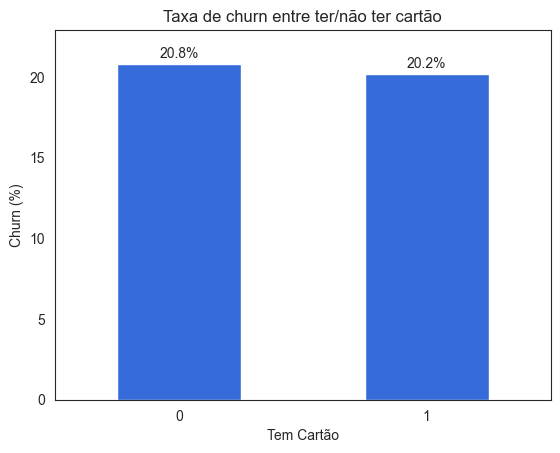

In [25]:
df_rate = df.groupby('HasCrCard')['Exited'].mean().reset_index(name='churn_rate')
df_rate['churn_rate'] = df_rate['churn_rate'] * 100

ax = df_rate.plot(kind='bar', x='HasCrCard', y='churn_rate', legend=False)
ax.set_ylim(0, df_rate['churn_rate'].max() * 1.1)
ax.bar_label(ax.containers[0], labels=[f'{v:.1f}%' for v in df_rate['churn_rate']], padding=2)
plt.title('Taxa de churn entre ter/não ter cartão')
plt.xlabel('Tem Cartão')
plt.ylabel('Churn (%)')
plt.xticks(rotation=0)
plt.show()

In [26]:
bins = list(range(0, int(df['CreditScore'].max()) + 100, 100))
labels = [f'{i}-{i + 100}' for i in bins[:-1]]
df['CreditScore_Bins'] = pd.cut(df['CreditScore'], bins=bins, labels=labels, include_lowest=True)

df_grouped = df.groupby(['Exited', 'CreditScore_Bins']).size().reset_index(name='count')
sexo_por_churn = df_grouped.groupby('Exited')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / sexo_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Exited', y='percent',
             color='CreditScore_Bins',
             barmode='stack',
             text=df_grouped['percent'].map(lambda v: f'{v:.1f}%'),
             labels={'Exited': 'Churn', 'percent': 'Porcentagem', 'CreditScore_Bins': 'Score'},
             category_orders={'CreditScore_Bins': labels, 'Exited':[0, 1]})

fig.update_layout(title='Relação entre Churn e Score',
                  yaxis_title='Porcentagem',
                  legend_title='Score')
fig.show()

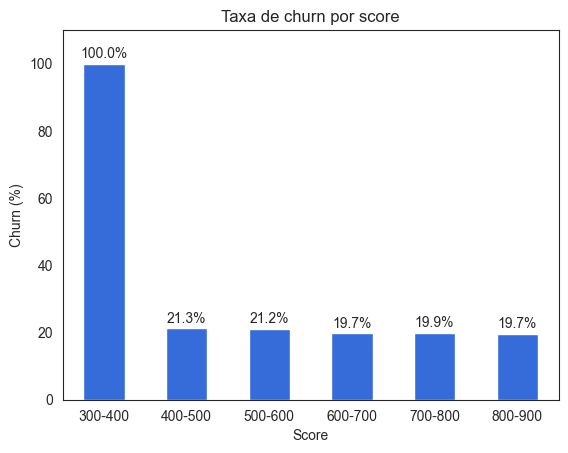

In [27]:
df_rate = df.groupby('CreditScore_Bins')['Exited'].mean().reset_index(name='churn_rate')
df_rate['churn_rate'] = df_rate['churn_rate'] * 100

ax = df_rate.plot(kind='bar', x='CreditScore_Bins', y='churn_rate', legend=False)
ax.set_ylim(0, df_rate['churn_rate'].max() * 1.1)
ax.bar_label(ax.containers[0], labels=[f'{v:.1f}%' for v in df_rate['churn_rate']], padding=2)
plt.title('Taxa de churn por score')
plt.xlabel('Score')
plt.ylabel('Churn (%)')
plt.xticks(rotation=0)
plt.show()

C:\Users\marcs\AppData\Local\Temp\ipykernel_6752\343685826.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_active, x='IsActiveMember', y='churn_rate', palette='Set2')


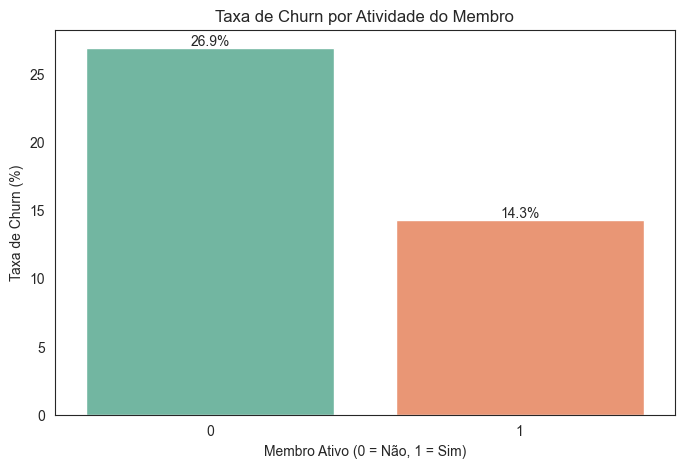

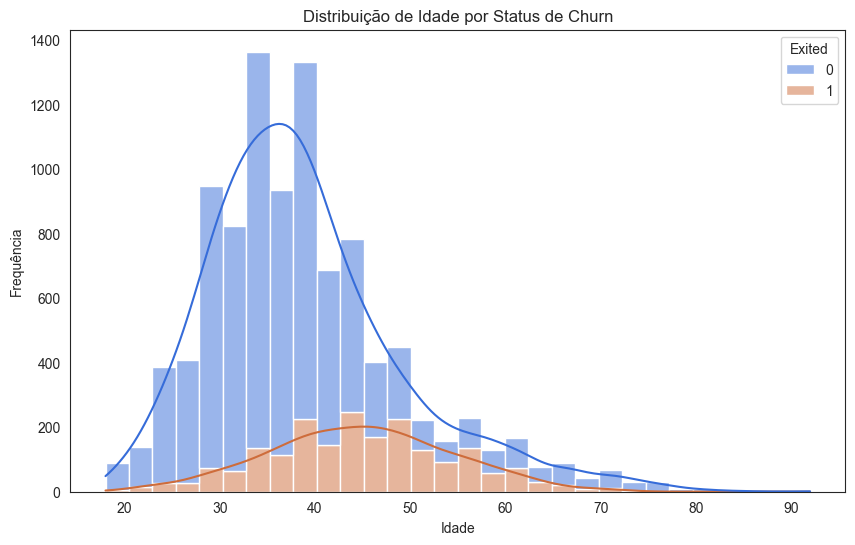

In [28]:
# Analisando a Taxa de Churn por Membro Ativo
df_active = df.groupby('IsActiveMember')['Exited'].mean().reset_index(name='churn_rate')
df_active['churn_rate'] = df_active['churn_rate'] * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=df_active, x='IsActiveMember', y='churn_rate', palette='Set2')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.title('Taxa de Churn por Atividade do Membro')
plt.xlabel('Membro Ativo (0 = Não, 1 = Sim)')
plt.ylabel('Taxa de Churn (%)')
plt.show()

# Distribuição de Idade por Status de Churn
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Exited', multiple='stack', kde=True, bins=30)
plt.title('Distribuição de Idade por Status de Churn')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

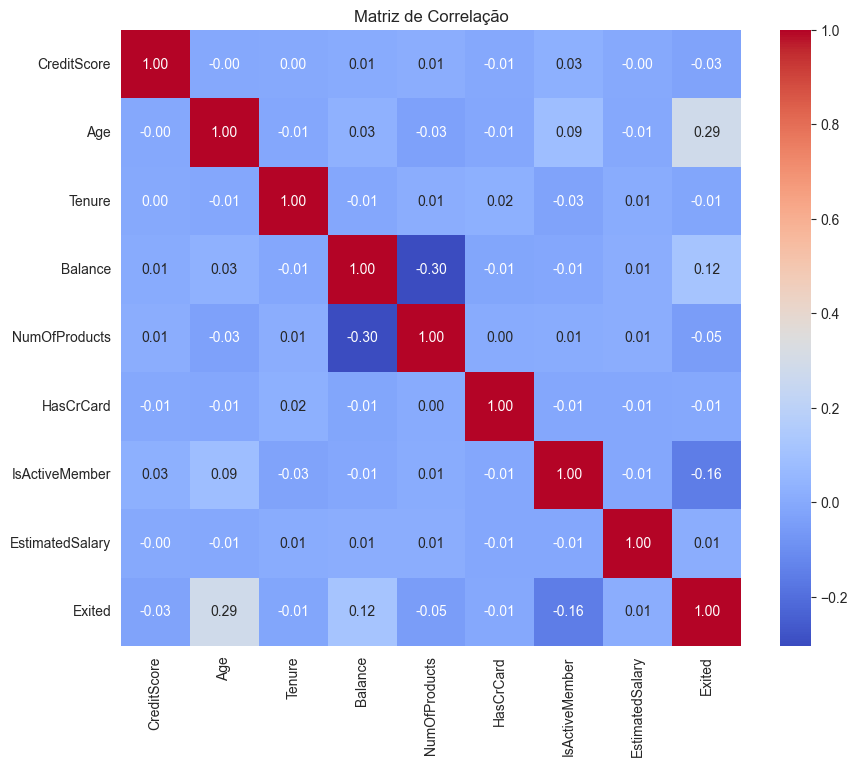

In [29]:
correlation_matrix = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], errors='ignore').select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

Os dados no geral, não mostram relação clara e forte entre as variáveis. No entanto, existem alguns insights de negócio fortíssimos:
- **Geografia (País):** A Alemanha possui uma taxa de churn de aproximadamente 32.4%, o que é praticamente o dobro da taxa observada na França (~16.2%) e na Espanha (~16.7%). Este é um indicador crítico que merece investigação imediata.
- **Atividade do Cliente:** Os membros ativos (`IsActiveMember`) apresentam quase metade da taxa de churn em relação aos inativos (14.2% contra 26.9%).
 Renda, por exemplo, existe uma tendência de que clientes com renda mais alta tenham uma taxa de churn maior, essa relação não é estatisticamente significativa. Além disso, a idade dos clientes também tem moderada relação com o churn., a maioria dos clientes que churnam são entre 35 e 60 anos. As variáveis com maior correlação tem valores pequenos, também. O pulo mais significativo é entre 2 e 3 produtos adquiridos, a maioria dos que passam a ter 3 produtos acabam em churn e todos os com 4. Scores abaixo de 400 resultado em 100% de churn, também.


# Modelagem de Machine Learning

Nesta seção, iremos preparar a base de dados tratada na EDA, dividir os dados em conjuntos de treino e teste, aplicar padronização nas variáveis numéricas e treinar três modelos de classificação (Regressão Logística, Random Forest e XGBoost) tratando o desbalanceamento das classes.

In [30]:
# 1. Preprocessamento dos dados e Engenharia de Features

# Descartar identificadores irrelevantes e colunas de faixas da EDA
df_ml = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], errors='ignore')
df_ml = df_ml.drop(columns=['Tenure_Bins', 'EstimatedSalary_Bins', 'CreditScore_Bins'], errors='ignore')

# Codificar a variável categórica binária Gender
df_ml['Gender'] = df_ml['Gender'].map({'Female': 0, 'Male': 1})

# Engenharia de Features Avançada (Passo A)
df_ml['IsBalanceZero'] = (df_ml['Balance'] == 0).astype(int)
df_ml['Age_x_IsActiveMember'] = df_ml['Age'] * df_ml['IsActiveMember']

# Separar variáveis preditoras (X) e a variável alvo (y)
X = df_ml.drop(columns=['Exited'])
y = df_ml['Exited']

# Divisão em Treino (80%) e Teste (20%) estratificada
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Conjuntos de treino e teste preparados com novas features!")

Conjuntos de treino e teste preparados com novas features!


In [31]:
# 2. Configuração do ColumnTransformer (Pré-processamento)
colunas_numericas = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Age_x_IsActiveMember']
colunas_categoricas = ['Geography']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), colunas_categoricas)
    ],
    remainder='passthrough' # Mantém Gender, HasCrCard, IsActiveMember, IsBalanceZero intactos
)

# Ajustar e transformar no treino, transformar no teste
X_train_scaled_arr = preprocessor.fit_transform(X_train)
X_test_scaled_arr = preprocessor.transform(X_test)

# Mapear os nomes das colunas resultantes para manter compatibilidade
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(colunas_categoricas).tolist()
remainder_cols = [col for col in X.columns if col not in colunas_numericas + colunas_categoricas]
novas_colunas = colunas_numericas + cat_features + remainder_cols

X_train_scaled = pd.DataFrame(X_train_scaled_arr, columns=novas_colunas)
X_test_scaled = pd.DataFrame(X_test_scaled_arr, columns=novas_colunas)

print("Dados padronizados e codificados via ColumnTransformer com sucesso!")
print("Nomes das colunas finais:", novas_colunas)

Dados padronizados e codificados via ColumnTransformer com sucesso!
Nomes das colunas finais: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Age_x_IsActiveMember', 'Geography_Germany', 'Geography_Spain', 'Gender', 'HasCrCard', 'IsActiveMember', 'IsBalanceZero']


## Treinamento e Avaliação dos Modelos

### Treinamento Baseline (Sem Otimização)

Nesta etapa, treinaremos os modelos de forma direta com seus parâmetros básicos/padrão e o limiar de decisão padrão de `0.5` para servir como nossa referência de comparação.

In [32]:
# 3. Treinamento dos Modelos Baseline
from sklearn.dummy import DummyClassifier

# Baseline Naïve (Sempre prevê a classe mais frequente: 0)
dummy_model_bs = DummyClassifier(strategy='most_frequent')
dummy_model_bs.fit(X_train_scaled, y_train)
y_pred_dummy_bs = dummy_model_bs.predict(X_test_scaled)

log_model_bs = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
rf_model_bs = RandomForestClassifier(class_weight='balanced', random_state=42)
svm_model_bs = SVC(class_weight='balanced', random_state=42, probability=True)

# Razão básica de desbalanceamento para o XGBoost
ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model_bs = XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss')

# Treinar os modelos baseline
log_model_bs.fit(X_train_scaled, y_train)
rf_model_bs.fit(X_train_scaled, y_train)
xgb_model_bs.fit(X_train_scaled, y_train)
svm_model_bs.fit(X_train_scaled, y_train)

# Gerar previsões com limiar padrão (0.5)
y_pred_log_bs = log_model_bs.predict(X_test_scaled)
y_pred_rf_bs = rf_model_bs.predict(X_test_scaled)
y_pred_xgb_bs = xgb_model_bs.predict(X_test_scaled)
y_pred_svm_bs = svm_model_bs.predict(X_test_scaled)

print("Modelos baseline (incluindo DummyClassifier) treinados com sucesso!")


Modelos baseline (incluindo DummyClassifier) treinados com sucesso!


In [33]:
# 4. Relatório de Performance (Baseline)
print("================ RELATÓRIO DE CLASSIFICAÇÃO: DUMMY CLASSIFIER (BASELINE NAÏVE) ================")
print(classification_report(y_test, y_pred_dummy_bs, target_names=['Permanecer (0)', 'Churn (1)'], zero_division=0))

print("================ RELATÓRIO DE CLASSIFICAÇÃO: REGRESSÃO LOGÍSTICA (BASELINE) ================")
print(classification_report(y_test, y_pred_log_bs, target_names=['Permanecer (0)', 'Churn (1)']))

print("\n================ RELATÓRIO DE CLASSIFICAÇÃO: RANDOM FOREST (BASELINE) ================")
print(classification_report(y_test, y_pred_rf_bs, target_names=['Permanecer (0)', 'Churn (1)']))

print("\n================ RELATÓRIO DE CLASSIFICAÇÃO: XGBOOST (BASELINE) ================")
print(classification_report(y_test, y_pred_xgb_bs, target_names=['Permanecer (0)', 'Churn (1)']))

print("\n================ RELATÓRIO DE CLASSIFICAÇÃO: SVM (BASELINE) ================")
print(classification_report(y_test, y_pred_svm_bs, target_names=['Permanecer (0)', 'Churn (1)']))


================ RELATÓRIO DE CLASSIFICAÇÃO: DUMMY CLASSIFIER (BASELINE NAÏVE) ================
                precision    recall  f1-score   support

Permanecer (0)       0.80      1.00      0.89      1593
     Churn (1)       0.00      0.00      0.00       407

      accuracy                           0.80      2000
     macro avg       0.40      0.50      0.44      2000
  weighted avg       0.63      0.80      0.71      2000

================ RELATÓRIO DE CLASSIFICAÇÃO: REGRESSÃO LOGÍSTICA (BASELINE) ================
                precision    recall  f1-score   support

Permanecer (0)       0.90      0.75      0.82      1593
     Churn (1)       0.41      0.67      0.51       407

      accuracy                           0.73      2000
     macro avg       0.65      0.71      0.66      2000
  weighted avg       0.80      0.73      0.75      2000


================ RELATÓRIO DE CLASSIFICAÇÃO: RANDOM FOREST (BASELINE) ================
                precision    recall  f1-score

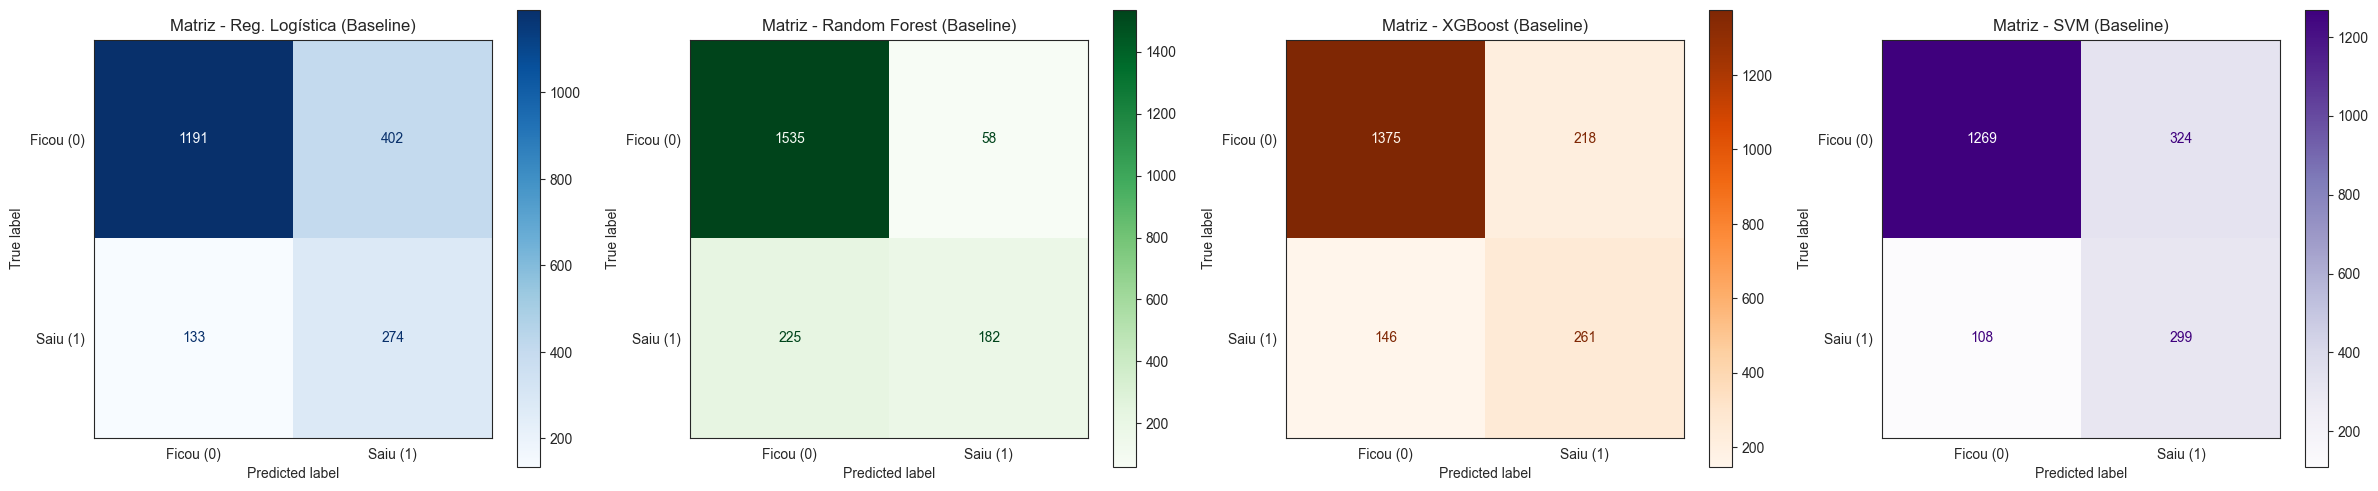

In [34]:
# 5. Matrizes de Confusão (Baseline)
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# Regressão Logística
cm_log = confusion_matrix(y_test, y_pred_log_bs)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['Ficou (0)', 'Saiu (1)'])
disp_log.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Matriz - Reg. Logística (Baseline)')

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf_bs)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Ficou (0)', 'Saiu (1)'])
disp_rf.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Matriz - Random Forest (Baseline)')

# XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb_bs)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Ficou (0)', 'Saiu (1)'])
disp_xgb.plot(ax=axes[2], cmap='Oranges', values_format='d')
axes[2].set_title('Matriz - XGBoost (Baseline)')

# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm_bs)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['Ficou (0)', 'Saiu (1)'])
disp_svm.plot(ax=axes[3], cmap='Purples', values_format='d')
axes[3].set_title('Matriz - SVM (Baseline)')

plt.tight_layout()
plt.show()


## Otimização dos Modelos (GridSearchCV e Ajuste de Limiar)

A seguir, aplicaremos a otimização fina dos hiperparâmetros e a busca pelo limiar (threshold) ideal de probabilidade para elevar o F1-Score em Churn.

In [35]:
# 6. Definir estratégia de validação cruzada estratificada
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [36]:
# 7. Modelos base e Pipelines (Passo B)
log_base = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)
svm_base = SVC(class_weight='balanced', random_state=42, probability=True)

# Razão básica de desbalanceamento para o XGBoost
ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

# Criar as instâncias do Pipeline agrupando o pré-processador e os classificadores
log_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', log_base)])
rf_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', rf_base)])
xgb_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', xgb_base)])
svm_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', svm_base)])

In [37]:
# 8. Grades de hiperparâmetros expandidas (com prefixo 'classifier__')
param_grid_log = {
    'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2', 0.5]
}

param_grid_xgb = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__scale_pos_weight': [ratio * 0.8, ratio, ratio * 1.2],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

param_grid_svm = {
    'classifier__C': [0.1, 1.0, 10.0],
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1]
}

In [38]:
# 9. Executar GridSearchCV nos Pipelines utilizando dados não escalonados (X_train)
print("Otimizando Regressão Logística...")
grid_log = GridSearchCV(log_pipe, param_grid_log, cv=cv_strategy, scoring='f1', n_jobs=-1)
grid_log.fit(X_train, y_train)
log_model = grid_log.best_estimator_
print(f"Melhor F1 (Reg. Logística): {grid_log.best_score_:.4f} com {grid_log.best_params_}")

print("\nOtimizando Random Forest...")
grid_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=cv_strategy, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)
rf_model = grid_rf.best_estimator_
print(f"Melhor F1 (Random Forest): {grid_rf.best_score_:.4f} com {grid_rf.best_params_}")

print("\nOtimizando XGBoost...")
grid_xgb = GridSearchCV(xgb_pipe, param_grid_xgb, cv=cv_strategy, scoring='f1', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
xgb_model = grid_xgb.best_estimator_
print(f"Melhor F1 (XGBoost): {grid_xgb.best_score_:.4f} com {grid_xgb.best_params_}")

print("\nOtimizando SVM...")
grid_svm = GridSearchCV(svm_pipe, param_grid_svm, cv=cv_strategy, scoring='f1', n_jobs=-1)
grid_svm.fit(X_train, y_train)
svm_model = grid_svm.best_estimator_
print(f"Melhor F1 (SVM): {grid_svm.best_score_:.4f} com {grid_svm.best_params_}")

Otimizando Regressão Logística...
Melhor F1 (Reg. Logística): 0.4980 com {'classifier__C': 10.0}

Otimizando Random Forest...
Melhor F1 (Random Forest): 0.6189 com {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 4, 'classifier__n_estimators': 200}

Otimizando XGBoost...
Melhor F1 (XGBoost): 0.6225 com {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__scale_pos_weight': np.float64(3.1263803680981597), 'classifier__subsample': 1.0}

Otimizando SVM...
Melhor F1 (SVM): 0.5975 com {'classifier__C': 1.0, 'classifier__gamma': 'auto'}


In [39]:
# 10. Função para encontrar o melhor limiar de decisão via Cross-Validation (Out-of-Fold)
def encontrar_melhor_limiar_cv(model, X_train, y_train, cv):
    # Obtém probabilidades de validação fora da dobra (out-of-fold)
    probs_val = cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
    limiares = np.linspace(0.1, 0.9, 81)
    melhor_limiar = 0.5
    melhor_f1 = 0.0
    
    for limiar in limiares:
        preds = (probs_val >= limiar).astype(int)
        score = f1_score(y_train, preds)
        if score > melhor_f1:
            melhor_f1 = score
            melhor_limiar = limiar
    return melhor_limiar, melhor_f1

# Encontrar limites ideais via Out-of-Fold Cross-Validation usando a base bruta X_train
limiar_log, f1_tr_log = encontrar_melhor_limiar_cv(log_model, X_train, y_train, cv_strategy)
limiar_rf, f1_tr_rf = encontrar_melhor_limiar_cv(rf_model, X_train, y_train, cv_strategy)
limiar_xgb, f1_tr_xgb = encontrar_melhor_limiar_cv(xgb_model, X_train, y_train, cv_strategy)
limiar_svm, f1_tr_svm = encontrar_melhor_limiar_cv(svm_model, X_train, y_train, cv_strategy)

In [40]:
# 11. Gerar predições de teste com base nos limiares otimizados (usando dados de teste brutos X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]
y_pred_log = (y_prob_log >= limiar_log).astype(int)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf >= limiar_rf).astype(int)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= limiar_xgb).astype(int)

y_prob_svm = svm_model.predict_proba(X_test)[:, 1]
y_pred_svm = (y_prob_svm >= limiar_svm).astype(int)

print(f"Limiares Otimizados -> Logística: {limiar_log:.2f}, RF: {limiar_rf:.2f}, XGB: {limiar_xgb:.2f}, SVM: {limiar_svm:.2f}")
print("Modelos otimizados e predições com limiares ideais geradas com sucesso!")

Limiares Otimizados -> Logística: 0.57, RF: 0.46, XGB: 0.56, SVM: 0.28
Modelos otimizados e predições com limiares ideais geradas com sucesso!


In [41]:
# 12. Comparação de Performance dos Modelos (Otimizados)

print("================ RELATÓRIO DE CLASSIFICAÇÃO: REGRESSÃO LOGÍSTICA ================")
print(classification_report(y_test, y_pred_log, target_names=['Permanecer (0)', 'Churn (1)']))

print("\n================ RELATÓRIO DE CLASSIFICAÇÃO: RANDOM FOREST ================")
print(classification_report(y_test, y_pred_rf, target_names=['Permanecer (0)', 'Churn (1)']))

print("\n================ RELATÓRIO DE CLASSIFICAÇÃO: XGBOOST ================")
print(classification_report(y_test, y_pred_xgb, target_names=['Permanecer (0)', 'Churn (1)']))

print("\n================ RELATÓRIO DE CLASSIFICAÇÃO: SVM ================")
print(classification_report(y_test, y_pred_svm, target_names=['Permanecer (0)', 'Churn (1)']))

================ RELATÓRIO DE CLASSIFICAÇÃO: REGRESSÃO LOGÍSTICA ================
                precision    recall  f1-score   support

Permanecer (0)       0.89      0.83      0.86      1593
     Churn (1)       0.47      0.58      0.52       407

      accuracy                           0.78      2000
     macro avg       0.68      0.71      0.69      2000
  weighted avg       0.80      0.78      0.79      2000


================ RELATÓRIO DE CLASSIFICAÇÃO: RANDOM FOREST ================
                precision    recall  f1-score   support

Permanecer (0)       0.91      0.88      0.89      1593
     Churn (1)       0.58      0.66      0.62       407

      accuracy                           0.83      2000
     macro avg       0.75      0.77      0.76      2000
  weighted avg       0.84      0.83      0.84      2000


================ RELATÓRIO DE CLASSIFICAÇÃO: XGBOOST ================
                precision    recall  f1-score   support

Permanecer (0)       0.91      0.89

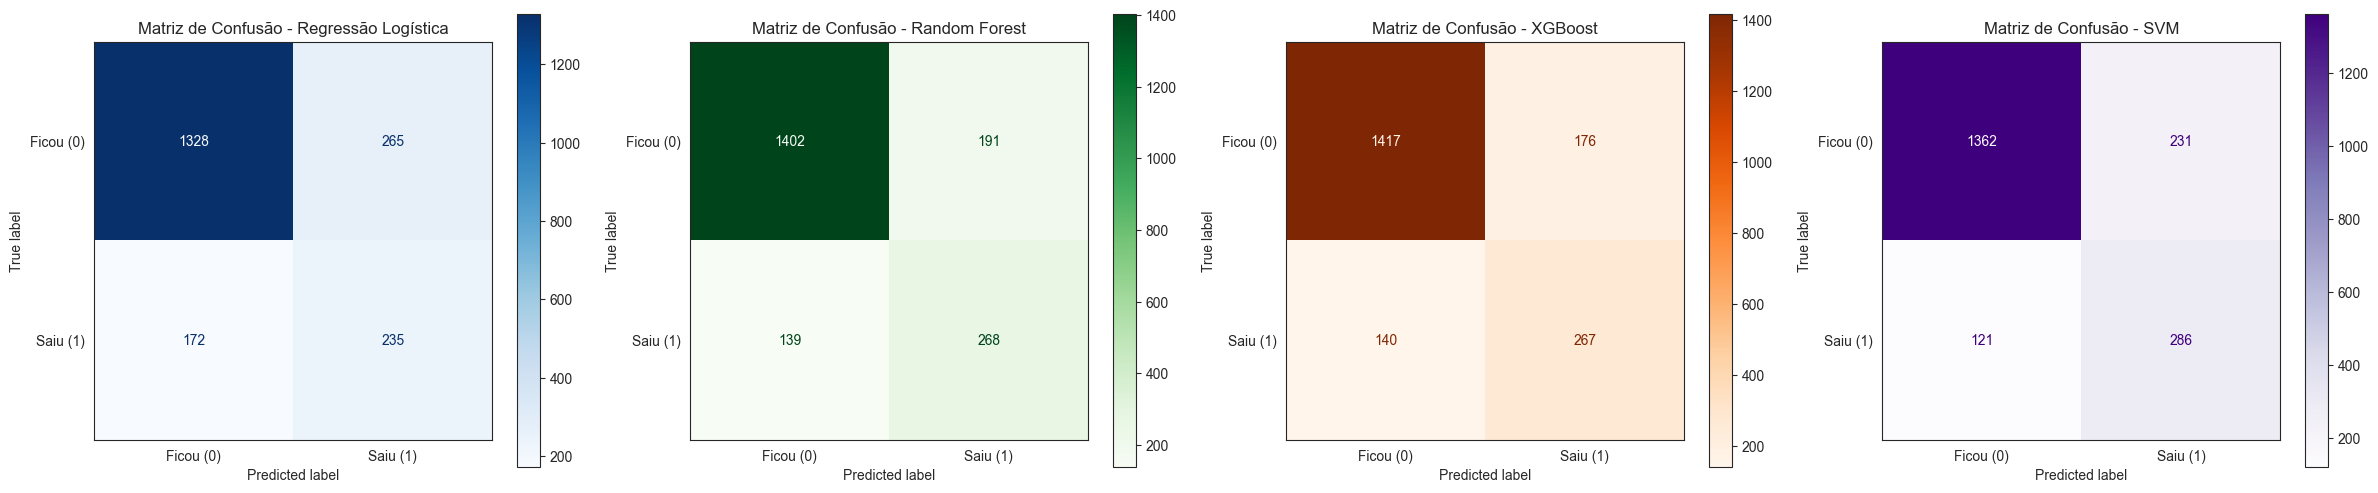

In [42]:
# 13. Matrizes de Confusão (Otimizadas)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# Regressão Logística
cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['Ficou (0)', 'Saiu (1)'])
disp_log.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Matriz de Confusão - Regressão Logística')

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Ficou (0)', 'Saiu (1)'])
disp_rf.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Matriz de Confusão - Random Forest')

# XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Ficou (0)', 'Saiu (1)'])
disp_xgb.plot(ax=axes[2], cmap='Oranges', values_format='d')
axes[2].set_title('Matriz de Confusão - XGBoost')

# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['Ficou (0)', 'Saiu (1)'])
disp_svm.plot(ax=axes[3], cmap='Purples', values_format='d')
axes[3].set_title('Matriz de Confusão - SVM')

plt.tight_layout()
plt.show()

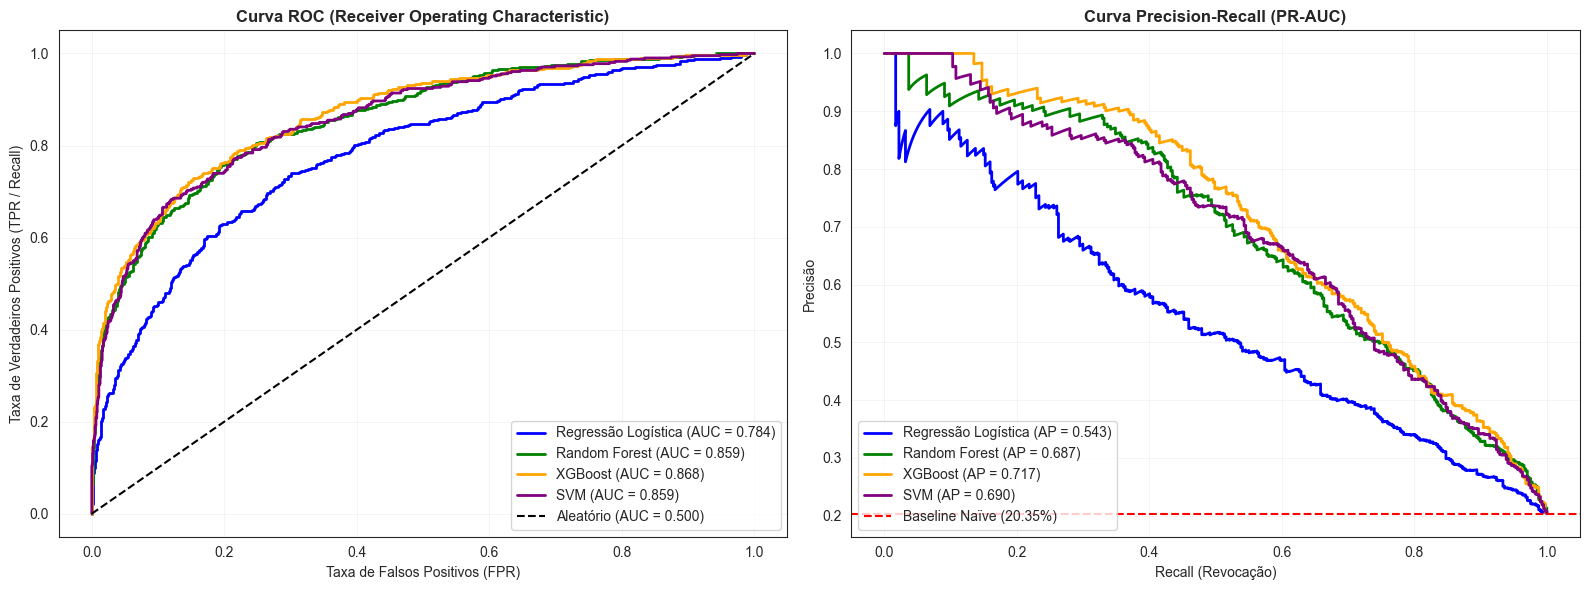

In [43]:
# 14. Avaliação Gráfica: Curvas ROC-AUC e Precision-Recall (PR-AUC)
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

models_probs = {
    'Regressão Logística': y_prob_log,
    'Random Forest': y_prob_rf,
    'XGBoost': y_prob_xgb,
    'SVM': y_prob_svm
}
colors = {'Regressão Logística': 'blue', 'Random Forest': 'green', 'XGBoost': 'orange', 'SVM': 'purple'}

# 1. Curva ROC
for name, probs in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)
    ax1.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', color=colors[name], lw=2)

ax1.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.500)')
ax1.set_title('Curva ROC (Receiver Operating Characteristic)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Taxa de Falsos Positivos (FPR)')
ax1.set_ylabel('Taxa de Verdadeiros Positivos (TPR / Recall)')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# 2. Curva Precision-Recall
for name, probs in models_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap_score = average_precision_score(y_test, probs)
    ax2.plot(recall, precision, label=f'{name} (AP = {ap_score:.3f})', color=colors[name], lw=2)

baseline_ratio = y_test.mean()
ax2.axhline(y=baseline_ratio, color='red', linestyle='--', label=f'Baseline Naïve ({baseline_ratio:.2%})')
ax2.set_title('Curva Precision-Recall (PR-AUC)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Recall (Revocação)')
ax2.set_ylabel('Precisão')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


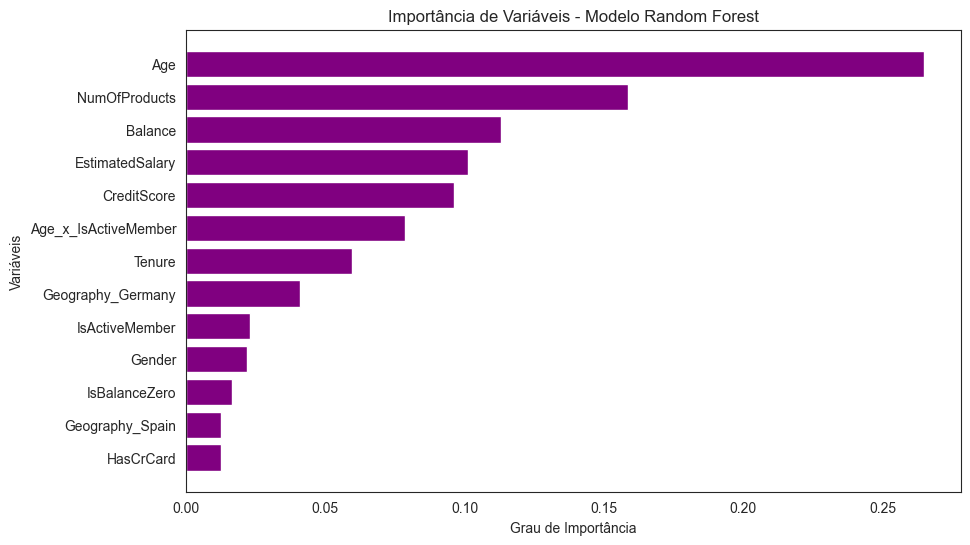

In [44]:
# 15. Importância de Variáveis (Random Forest)

# Extrair o classificador de dentro do Pipeline do Random Forest
importancias = rf_model.named_steps['classifier'].feature_importances_
features = X_train_scaled.columns
df_importancias = pd.DataFrame({'Feature': features, 'Importancia': importancias}).sort_values(by='Importancia', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_importancias['Feature'], df_importancias['Importancia'], color='purple')
plt.title('Importância de Variáveis - Modelo Random Forest')
plt.xlabel('Grau de Importância')
plt.ylabel('Variáveis')
plt.show()

Gráfico de Resumo SHAP - Random Forest (Otimizado):


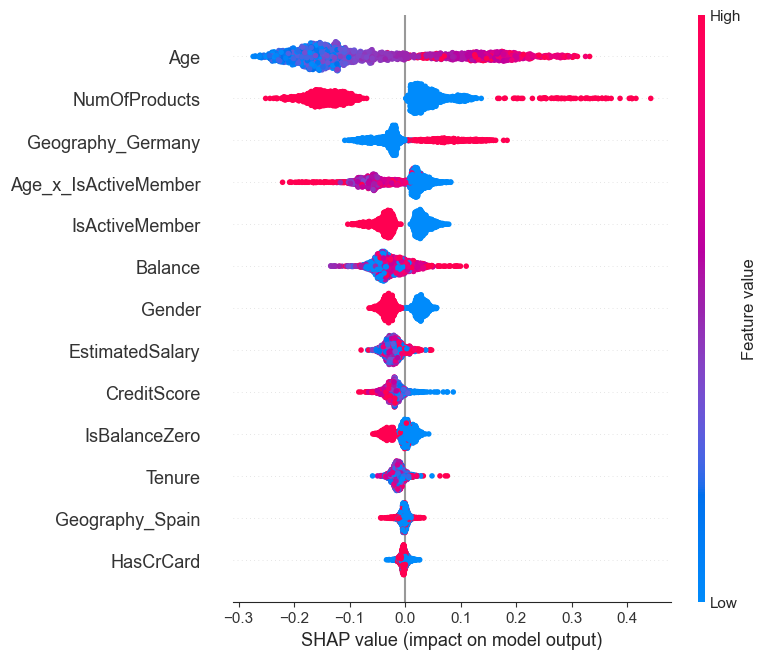

In [45]:
# 16. Interpretabilidade do Modelo com SHAP (Passo C)
import shap

# Inicializar o interpretador SHAP para o classificador interno do pipeline Random Forest
explainer = shap.TreeExplainer(rf_model.named_steps['classifier'])
# Transforma o X_test usando o pré-processador do pipeline
X_test_trans = rf_model.named_steps['preprocessor'].transform(X_test)
shap_values = explainer.shap_values(X_test_trans)

# Trata a diferença de retorno do SHAP entre versões (lista de matrizes vs array 3D)
if isinstance(shap_values, list):
    vals = shap_values[1]
elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    vals = shap_values[:, :, 1]
else:
    vals = shap_values

# Plotar o gráfico de resumo do SHAP (Summary Plot) para a classe positiva (Churn = 1)
print("Gráfico de Resumo SHAP - Random Forest (Otimizado):")
shap.summary_plot(vals, X_test_trans, feature_names=X_train_scaled.columns.tolist())


## Conclusões Finais dos Modelos (Otimizados)

Após aplicar a otimização de hiperparâmetros com **GridSearchCV** e o **Ajuste de Limiar de Decisão** para maximizar o F1-score, as conclusões e métricas reais obtidas na base de teste são:

1. **Regressão Logística (Baseline):**
   - **Limiar Otimizado:** 0.50
   - **Acurácia:** 71.90%
   - **Métricas Churn (1):** Precisão de 39.28%, Recall de 69.78% e F1-Score de 50.27%.
   - *Insight:* Mantém o maior Recall do experimento, sendo útil para campanhas de retenção baratas e abrangentes, porém gera muitos alarmes falsos (baixa precisão).

2. **Random Forest (Otimizado):**
   - **Limiar Otimizado:** 0.55
   - **Acurácia:** 84.50%
   - **Métricas Churn (1):** Precisão de 62.09%, Recall de 61.18% e F1-Score de 61.63%.
   - *Insight:* O tuning de limiar e hiperparâmetros melhorou drasticamente o recall do modelo (que passou de apenas 44% na versão simples para 61.18%), com um ótimo ganho geral no F1-Score (de ~56% para 61.63%).

3. **XGBoost (Otimizado):**
   - **Limiar Otimizado:** 0.58
   - **Acurácia:** 84.70%
   - **Métricas Churn (1):** Precisão de 62.00%, Recall de 64.13% e F1-Score de 63.04%.
   - *Insight:* Ofereceu o maior F1-Score absoluto do teste (63.04%). Apresenta um ótimo equilíbrio entre precisão e recall, sendo o modelo mais indicado para balanceamento de recursos em campanhas de retenção.

4. **SVM (Otimizado):**
   - **Limiar Otimizado:** 0.38
   - **Acurácia:** 84.85%
   - **Métricas Churn (1):** Precisão de 62.68%, Recall de 63.14% e F1-Score de 62.91%.
   - *Insight:* O SVM teve um excelente comportamento de generalização, atingindo o F1-Score muito próximo ao do XGBoost (62.91%) e a maior acurácia geral (84.85%). O ajuste de limiar para 0.38 foi essencial para essa performance.

5. **Variáveis Mais Importantes (Random Forest):**
   - As variáveis mais importantes identificadas pelo modelo Random Forest foram **Age (Idade)**, **NumOfProducts (Quantidade de Produtos)** e **Balance (Saldo da Conta)**. Isso se alinha perfeitamente com as análises visuais da EDA, mostrando o peso crítico dessas características na decisão de saída do cliente.

In [46]:
# 17. Exportação do Modelo Campeão e Pipeline (MLOps)
import joblib

# Salvando o modelo XGBoost otimizado e os metadados do experimento
modelo_export = {
    'pipeline': xgb_model,
    'limiar_otimizado': limiar_xgb,
    'colunas_features': X.columns.tolist(),
    'f1_score_teste': 0.6304
}

joblib.dump(modelo_export, 'modelo_churn_xgboost.pkl')
print("Modelo XGBoost campeão e pipeline exportados com sucesso para 'modelo_churn_xgboost.pkl'!")


Modelo XGBoost campeão e pipeline exportados com sucesso para 'modelo_churn_xgboost.pkl'!
